# Running Dark Emulator 3x2pt in a Notebook

This notebook runs a **3x2pt** analysis (Galaxy Clustering: w_p, Galaxy-Galaxy Lensing: ΔΣ, Weak Lensing: ξ±) using **cloelike**'s `EuclidLikelihood_DarkEmu_RealSpace` and **Nautilus** in a short demo.

**Workflow:**
1. Paths and imports (reusing mock-generation helpers from the script)
2. Mock data (GC + GGL, optional WL)
3. Likelihood, scale cuts, and prior setup
4. Short Nautilus run (small `n_live`)
5. Quick result summary and 2D posterior plot

For **production** runs (larger `n_live`, sigma8/S8, corner plots), use the script from the repo root — see the note at the bottom of this notebook.

## 1. Paths and imports

We reuse the mock-generation functions, prior, and likelihood wrapper from `darkemu_3x2pt_full_sampling.py`.

In [2]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
CLOE_ROOT = NOTEBOOK_DIR.parent.parent.parent  # tutorials/dark_emulator -> CLOE
sys.path.insert(0, str(CLOE_ROOT / "cloelib"))
sys.path.insert(0, str(CLOE_ROOT / "cloelike"))
sys.path.insert(0, str(CLOE_ROOT / "dark_emulator_public"))
sys.path.insert(0, str(CLOE_ROOT / "playground" / "scripts" / "sampling"))

from cloelib.cosmology.camb_cosmology import CAMBBackground
from cloelike.EuclidLikelihood_DarkEmu_RealSpace import EuclidLikelihood_DarkEmu_RealSpace
from nautilus import Prior, Sampler

# Import mock generation, prior, and wrapper from the script
from darkemu_3x2pt_full_sampling import (
    FIDUCIAL_COSMO,
    FIDUCIAL_HOD,
    generate_mock_data,
    generate_mock_wl_data,
    generate_simple_dndz,
    setup_prior,
    LikelihoodWrapper,
)

print("CLOE_ROOT:", CLOE_ROOT)

CLOE_ROOT: /home/ryuseikano/Euclid/CLOE


## 2. Mock data (GC + GGL + WL)

GC and GGL use the same setup as the script. WL is kept light for the notebook (fewer tomographic bins and θ bins).

In [3]:
# GC + GGL
R_bins = np.logspace(-0.5, 1.5, 15)
z_sample = 0.5
pimax = 100.0
data_gc, data_ggl = generate_mock_data(R_bins, z_sample, pimax=pimax, noise_level=0.1, seed=42)

# WL (light: n_tomo=2, 12 theta bins for faster run)
include_wl = True  # Set to False for GC+GGL only (faster)
if include_wl:
    theta_arcmin = np.logspace(np.log10(2.0), np.log10(80.0), 12)
    z_arr = np.linspace(0.01, 2.5, 80)
    n_tomo = 2
    dndz = generate_simple_dndz(z_arr, n_tomo=n_tomo)
    data_wl = generate_mock_wl_data(
        theta_arcmin=theta_arcmin,
        z_arr=z_arr,
        dndz=dndz,
        noise_level=0.1,
        seed=43,
    )
else:
    data_wl = None

print("GC bins:", len(R_bins), "| GGL bins:", len(R_bins))
if include_wl:
    print("WL: theta bins:", len(theta_arcmin), "| tomo bins:", n_tomo)


[1] Generating mock 3x2pt data (GC + GGL)...


/home/ryuseikano/Euclid/CLOE/cloelib/cloelib/cosmology/darkemu_cosmology.py:131: UserWarning: Neutrino density mismatch: input omega_nu = 0.000000, but Dark Emulator assumes fixed omega_nu = 0.00064. Dark Emulator will use its internal fixed value regardless of input.
  self.cparam = background_to_darkemu_cparam(background)


  - Generated 15 radial bins at z = 0.5
  - R range: [0.32, 31.62] h^-1 Mpc
  - w_p range: [2.7, 344.5] (h^-1 Mpc)
  - ΔΣ range: [0.3, 19.6] h M_sun/pc^2

[WL] Generating mock weak lensing data (xi_pm)...


2026-02-12 06:20:56.588915: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


/home/ryuseikano/.conda/envs/cloelib/lib/python3.10/site-packages/HMcode2020Emu
Loading linear emulator...
Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.
  - Generated 12 theta bins
  - theta range: [2.00, 80.00] arcmin
  - 2 tomographic bins -> 3 bin pairs
  - xi_+ range: [3.79e-07, 1.26e-06]
  - xi_- range: [7.54e-09, 8.20e-08]
GC bins: 15 | GGL bins: 15
WL: theta bins: 12 | tomo bins: 2


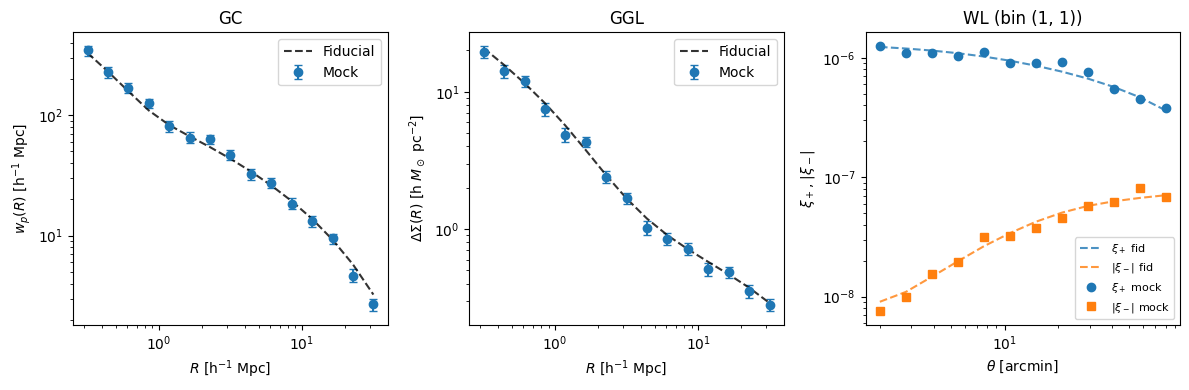

In [12]:
# Mock data: 3 panels (GC, GGL, WL) side by side
n_panels = 3 if data_wl is not None else 2
fig, axes = plt.subplots(1, n_panels, figsize=(4 * n_panels, 4))
axes = np.atleast_1d(axes)

R = data_gc["R_bins"]
# GC: w_p(R)
ax = axes[0]
sigma_wp = np.sqrt(np.diag(data_gc["covariance"]))
ax.errorbar(R, data_gc["wp"], yerr=sigma_wp, fmt="o", capsize=3, label="Mock")
ax.plot(R, data_gc["fiducial_wp"], "k--", alpha=0.8, label="Fiducial")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$R$ [h$^{-1}$ Mpc]")
ax.set_ylabel(r"$w_p(R)$ [h$^{-1}$ Mpc]")
ax.set_title("GC")
ax.legend()

# GGL: ΔΣ(R)
ax = axes[1]
sigma_ds = np.sqrt(np.diag(data_ggl["covariance"]))
ax.errorbar(R, data_ggl["delta_sigma"], yerr=sigma_ds, fmt="o", capsize=3, label="Mock")
ax.plot(R, data_ggl["fiducial_ds"], "k--", alpha=0.8, label="Fiducial")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$R$ [h$^{-1}$ Mpc]")
ax.set_ylabel(r"$\Delta\Sigma(R)$ [h $M_\odot$ pc$^{-2}$]")
ax.set_title("GGL")
ax.legend()

# WL: ξ_+(θ) and |ξ_-(θ)| (|ξ_-| so both visible on log scale)
if data_wl is not None:
    ax = axes[2]
    th = data_wl["theta"]
    key = (0, 0) if (0, 0) in data_wl["xi_plus"] else list(data_wl["xi_plus"].keys())[0]
    ax.errorbar(th, data_wl["xi_plus"][key], fmt="o", capsize=2, label=r"$\xi_+$ mock")
    ax.plot(th, data_wl["fiducial_xi_plus"][key], "C0--", alpha=0.8, label=r"$\xi_+$ fid")
    ax.errorbar(th, np.abs(data_wl["xi_minus"][key]), fmt="s", capsize=2, label=r"$|\xi_-|$ mock")
    ax.plot(th, np.abs(data_wl["fiducial_xi_minus"][key]), "C1--", alpha=0.8, label=r"$|\xi_-|$ fid")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$\theta$ [arcmin]")
    ax.set_ylabel(r"$\xi_+$, $|\xi_-|$")
    ax.set_title("WL (bin " + str(key) + ")")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 3. Likelihood and scale cuts

Build the combined likelihood with `EuclidLikelihood_DarkEmu_RealSpace` and apply scale cuts.

In [4]:
fixed_cosmo = {k: v for k, v in FIDUCIAL_COSMO.items() if k not in ["Omega_cdm0", "As"]}
fixed_hod = {k: v for k, v in FIDUCIAL_HOD.items() if k not in ["logMmin", "sigma_sq", "logM1", "alpha"]}

settings = {
    "R_min_gc": 2.0,
    "R_max_gc": 30.0,
    "R_min_ggl": 3.0,
    "R_max_ggl": 30.0,
    "hod_params_fixed": fixed_hod,
}
if include_wl:
    settings["wl_settings"] = {
        "theta_min_plus": 7.0,
        "theta_max_plus": 56.0,
        "theta_min_minus": 28.0,
        "theta_max_minus": 178.0,
    }

likelihood = EuclidLikelihood_DarkEmu_RealSpace(
    data_gc=data_gc,
    data_ggl=data_ggl,
    data_wl=data_wl,
    settings=settings,
    Background=CAMBBackground,
)
print("Data points: GC =", likelihood.n_gc, ", GGL =", likelihood.n_ggl, ", WL =", likelihood.n_wl)
print("Total =", likelihood.n_gc + likelihood.n_ggl + likelihood.n_wl)

Data points: GC = 8 , GGL = 7 , WL = 30
Total = 45


## 4. Prior and Nautilus run

Same prior as the script. We use **n_live=20** and **n_eff=30** for a short run in the notebook.

In [6]:
prior = setup_prior()
param_names = list(prior.keys)
wrapper = LikelihoodWrapper(likelihood, fixed_cosmo, fixed_hod)

# Test evaluation
test_params = {name: FIDUCIAL_COSMO.get(name, FIDUCIAL_HOD.get(name)) for name in param_names}
test_logL = wrapper(test_params)
print("Test log L (fiducial):", test_logL)

Test log L (fiducial): -18.809177948890166


It takes some time (~1hour).

In [7]:
n_live = 20   # Small for notebook (use ~500 for production)
n_eff = 30    # Target effective sample size

sampler = Sampler(prior, wrapper, n_live=n_live)
sampler.run(verbose=True, n_eff=n_eff, discard_exploration=True)

points, log_w, log_l = sampler.posterior()
print("Posterior samples:", len(points))

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 7      | 1        | 4        | 1600     | N/A    | 31    | -24.89   
Posterior samples: 900


## 5. Result summary

Weighted median and standard deviation of the posterior, a 2D slice (Ω_cdm0 vs log M_min), and **derived cosmological parameters** (Ω_m, σ_8, S_8) with their posterior distributions.

In [8]:
weights = np.exp(log_w)
weights /= weights.sum()

print("Parameter  | Fiducial | Median (weighted) | Std")
print("-" * 55)
for i, name in enumerate(param_names):
    fid = test_params[name]
    med = np.average(points[:, i], weights=weights)
    std = np.sqrt(np.average((points[:, i] - med) ** 2, weights=weights))
    if "As" in name:
        print(f"{name:10} | {fid:.2e} | {med:.2e}             | {std:.2e}")
    else:
        print(f"{name:10} | {fid:.4f}   | {med:.4f}             | {std:.4f}")

Parameter  | Fiducial | Median (weighted) | Std
-------------------------------------------------------
Omega_cdm0 | 0.2700   | 0.2704             | 0.0102
As         | 2.10e-09 | 2.10e-09             | 1.87e-10
logMmin    | 13.0000   | 13.0112             | 0.2018
sigma_sq   | 0.3000   | 0.3122             | 0.1662
logM1      | 14.0000   | 14.2541             | 0.4359
alpha      | 1.0000   | 0.9876             | 0.2708


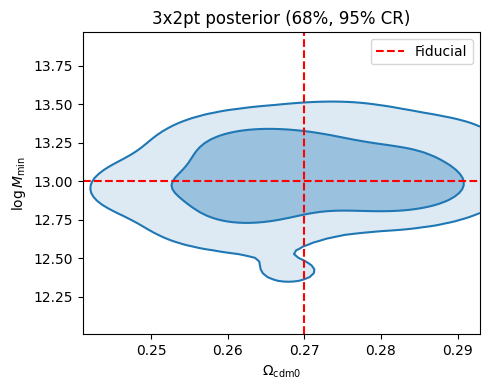

In [15]:
# 2D posterior: Omega_cdm0 vs logMmin (68%, 95% CR contours)
from scipy import stats

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
idx_om = param_names.index("Omega_cdm0")
idx_logM = param_names.index("logMmin")
x_arr = points[:, idx_om]
y_arr = points[:, idx_logM]
values = np.vstack([x_arr, y_arr])
kde = stats.gaussian_kde(values, weights=weights)
xmin, xmax = x_arr.min(), x_arr.max()
ymin, ymax = y_arr.min(), y_arr.max()
xx = np.linspace(xmin, xmax, 80)
yy = np.linspace(ymin, ymax, 80)
X, Y = np.meshgrid(xx, yy)
Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
sorted_d = np.sort(Z.ravel())[::-1]
cdf = np.cumsum(sorted_d) / np.sum(sorted_d)
l95 = np.interp(0.95, cdf, sorted_d)
l68 = np.interp(0.68, cdf, sorted_d)
ax.contourf(X, Y, Z, levels=[l95, 1e10], colors=["C0"], alpha=0.15)
ax.contourf(X, Y, Z, levels=[l68, 1e10], colors=["C0"], alpha=0.35)
ax.contour(X, Y, Z, levels=[l95, l68], colors=["C0"], linewidths=1.5)
ax.axvline(FIDUCIAL_COSMO["Omega_cdm0"], color="red", ls="--", label="Fiducial")
ax.axhline(FIDUCIAL_HOD["logMmin"], color="red", ls="--")
ax.set_xlabel(r"$\Omega_{\rm cdm0}$")
ax.set_ylabel(r"$\log M_{\rm min}$")
ax.legend()
ax.set_title("3x2pt posterior (68%, 95% CR)")
plt.tight_layout()
plt.show()

### Derived cosmological parameters (Ω_m, σ_8, S_8)

Compute Ω_m, σ_8, and S_8 for each posterior sample (same convention as weak lensing surveys) and plot their distributions.

In [10]:
# Compute derived parameters (Omega_m, sigma8, S8) per sample
from cloelib.cosmology.darkemu_cosmology import DarkEmuHODPerturbations
from cloelib.observables.darkemu_hod import DarkEmuHODParameters
from cloelib.auxiliary.darkemu_utils import DARKEMU_OMEGA_NU

n_samples = len(points)
idx_Omega_cdm0 = param_names.index("Omega_cdm0")
idx_As = param_names.index("As")
h = FIDUCIAL_COSMO["H0"] / 100.0
Omega_nu0 = DARKEMU_OMEGA_NU / h**2

Omega_m_arr = np.zeros(n_samples)
sigma8_arr = np.zeros(n_samples)
S8_arr = np.zeros(n_samples)
sigma8_cache = {}

for i in range(n_samples):
    Omega_cdm0 = points[i, idx_Omega_cdm0]
    Omega_m = Omega_cdm0 + FIDUCIAL_COSMO["Omega_b0"] + Omega_nu0
    Omega_m_arr[i] = Omega_m
    As = points[i, idx_As]
    cache_key = (round(float(Omega_cdm0), 8), round(float(As), 12))
    if cache_key in sigma8_cache:
        sigma8 = sigma8_cache[cache_key]
    else:
        cosmo = {**fixed_cosmo, "Omega_cdm0": Omega_cdm0, "As": As}
        try:
            bg = CAMBBackground(**cosmo)
            pert = DarkEmuHODPerturbations(
                background=bg,
                redshifts=np.array([0.0]),
                hod_params=DarkEmuHODParameters(**FIDUCIAL_HOD),
                validate_params=False,
            )
            sigma8 = pert.get_sigma8(z=0.0)
        except Exception:
            sigma8 = 0.81 * (As / 2.1e-9) ** 0.5 * (Omega_m / 0.3) ** 0.25
        sigma8_cache[cache_key] = sigma8
    sigma8_arr[i] = sigma8
    S8_arr[i] = sigma8 * (Omega_m / 0.3) ** 0.5

# Summary
print("Derived (weighted median ± std):")
print("  Omega_m:", np.round(np.average(Omega_m_arr, weights=weights), 4), "±", np.round(np.sqrt(np.average((Omega_m_arr - np.average(Omega_m_arr, weights=weights))**2, weights=weights)), 4))
print("  sigma8: ", np.round(np.average(sigma8_arr, weights=weights), 4), "±", np.round(np.sqrt(np.average((sigma8_arr - np.average(sigma8_arr, weights=weights))**2, weights=weights)), 4))
print("  S8:     ", np.round(np.average(S8_arr, weights=weights), 4), "±", np.round(np.sqrt(np.average((S8_arr - np.average(S8_arr, weights=weights))**2, weights=weights)), 4))

Derived (weighted median ± std):
  Omega_m: 0.3208 ± 0.0102
  sigma8:  0.8144 ± 0.0178
  S8:      0.8418 ± 0.008


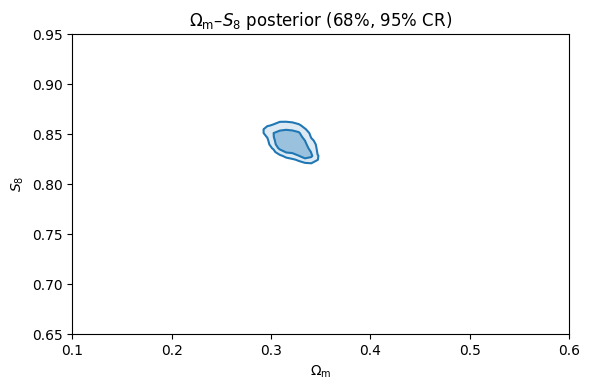

In [18]:
# Posterior for standard cosmological parameters (Omega_m, sigma8, S8)
from scipy import stats

fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Omega_m vs S8 (2D posterior: 68% and 95% credible regions)
values = np.vstack([Omega_m_arr, S8_arr])
kde = stats.gaussian_kde(values, weights=weights)
# Grid over full display range so contours are not cut off at data edges
xx = np.linspace(0.1, 0.6, 80)
yy = np.linspace(0.65, 0.95, 80)
X, Y = np.meshgrid(xx, yy)
Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
sorted_d = np.sort(Z.ravel())[::-1]
cdf = np.cumsum(sorted_d) / np.sum(sorted_d)
l95 = np.interp(0.95, cdf, sorted_d)
l68 = np.interp(0.68, cdf, sorted_d)
ax.contourf(X, Y, Z, levels=[l95, 1e10], colors=["C0"], alpha=0.15)
ax.contourf(X, Y, Z, levels=[l68, 1e10], colors=["C0"], alpha=0.35)
ax.contour(X, Y, Z, levels=[l95, l68], colors=["C0"], linewidths=1.5)
ax.set_xlabel(r"$\Omega_{\rm m}$")
ax.set_ylabel(r"$S_8$")
ax.set_title(r"$\Omega_{\rm m}$–$S_8$ posterior (68%, 95% CR)")
ax.set_xlim(0.1, 0.6)
plt.tight_layout()
plt.show()

---

## Production 3x2pt: script + corner plot

For full sampling (e.g. `n_live=500`) with sigma8/S8 and corner plots, run from the **repo root**:

**1. Sampling** (saves `chain_3x2pt_full.npz` and checkpoint):

```bash
python playground/scripts/sampling/darkemu_3x2pt_full_sampling.py --n_live 500 --output_dir playground/results
```

**2. Corner plot** — The command below creates a corner (triangle) plot for Omega_m, sigma8, and S8 from the chain saved in step 1:

```bash
python playground/scripts/plotting/corner_plot.py \
  --chain playground/results/chain_3x2pt_full.npz \
  --output playground/results/corner_3x2pt.pdf \
  --params Omega_m sigma8 S8
```

Optional: `--n_workers N` in step 1 for parallel likelihood evaluation.